# Preparación de Dataset

En este Script se realiza la descarga de los datos base para el entrenamiento, se realizará la clasificacion de señales provenientes de detectores de centelleo para Gamma y Neutrones, los datos originales seran descargados desde [El siguiente link](https://zenodo.org/records/8037239), aqui se obtendran las señales de `neutron.csv` y `gamma.csv`.   

In [13]:
# Import libraries

import requests
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Descarga de datos

A continuacion se verifica si los datos se encuentran en la carpeta o si no, se descarga desde el link oficial.

In [14]:
data_dir = Path('dataset')
data_dir.mkdir(exist_ok=True)

files = {
    "gamma.csv": "https://zenodo.org/records/8037239/files/gamma.csv?download=1",
    "neutron.csv": "https://zenodo.org/records/8037239/files/neutron.csv?download=1"
}

for filename, url in files.items():
    filepath = data_dir / filename
    if not filepath.exists():
        print(f"Downloading {filename}...")
        res = requests.get(url)
        res.raise_for_status()  # Check if the request was successful

        with open(filepath, 'wb') as f:
            f.write(res.content)
    else:
        print(f"{filename} already exists. Skipping download.")

gamma.csv already exists. Skipping download.
neutron.csv already exists. Skipping download.


### Carga y exploración de Dataset

Aqui se realizara la carga y exploracion del dataset, tambien la reduccion de dimensiones para el desarrollo de la red neuronal

In [15]:
neutron = pd.read_csv('dataset/neutron.csv')
gamma = pd.read_csv('dataset/gamma.csv')

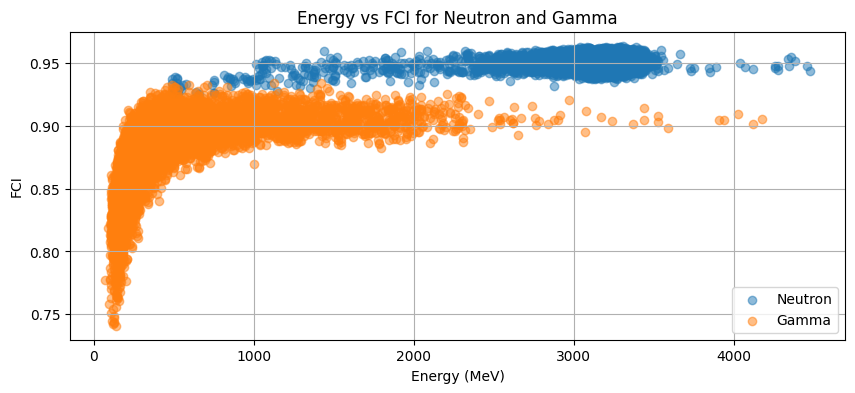

In [16]:
plt.figure(figsize=(10, 4))
plt.scatter(neutron['Energy'], neutron['FCI'], label='Neutron', alpha=0.5)
plt.scatter(gamma['Energy'], gamma['FCI'], label='Gamma', alpha=0.5)
plt.xlabel('Energy (MeV)')
plt.ylabel('FCI')
plt.title('Energy vs FCI for Neutron and Gamma')
plt.legend()
plt.grid()
plt.show()

Gamma dataset shape:  (10913, 3004)
Neutron dataset shape:  (27696, 3004)


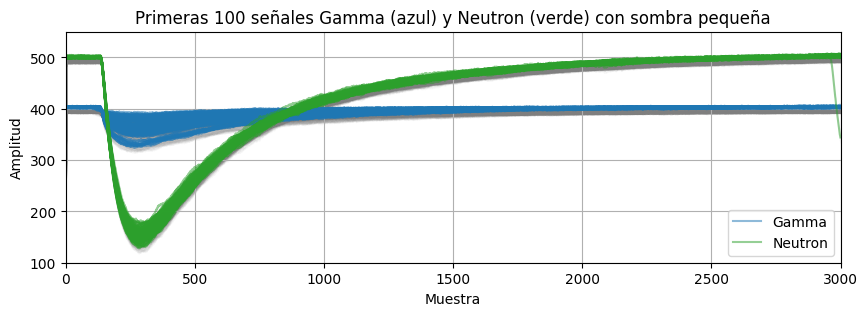

In [17]:
# Explore datasets and plot some signals
print("Gamma dataset shape: ", gamma.shape)
print("Neutron dataset shape: ", neutron.shape)
gamma.head()
neutron.head()

plt.figure(figsize=(10, 3))

# Graficar 40 señales gamma en azul con sombra pequeña debajo de la línea
for i in range(100):
    y = gamma.iloc[i, :-4]
    x = range(len(y))
    plt.plot(x, y, color='tab:blue', alpha=0.5, label='Gamma' if i == 0 else "")
    plt.fill_between(x, y, y-10, color='tab:gray', alpha=0.05)  # Sombra pequeña

# Graficar 40 señales neutron en verde con sombra pequeña debajo de la línea
for i in range(100):
    y = neutron.iloc[i, :-4]
    x = range(len(y))
    plt.plot(x, y, color='tab:green', alpha=0.5, label='Neutron' if i == 0 else "")
    plt.fill_between(x, y, y-10, color='tab:gray', alpha=0.05)  # Sombra pequeña

plt.title("Primeras 100 señales Gamma (azul) y Neutron (verde) con sombra pequeña")
plt.xlabel("Muestra")
plt.ylabel("Amplitud")
plt.xlim(0, 3000)
plt.ylim(100, 550)
plt.legend()
plt.grid()
plt.show()

### Tomar 161 datos para cada muestra de señal

La señal original cuenta con 3000 muestras, pero para efectos de la red neuronal que implementaremos en la FPGA solo tomaremos 161 muestras

In [18]:
neutron_vect = np.array(neutron.iloc[:, :-4])
gamma_vect = np.array(gamma.iloc[:, :-4])

indices = np.linspace(100, 2500 - 1, 161, dtype=int)
newNeutron = neutron_vect[:, indices]
newGamma = gamma_vect[:, indices]

### Creación de Datasets para entrenamiento y test

In [19]:
# Convertir a DataFrame
df_neutron = pd.DataFrame(newNeutron)
df_gamma = pd.DataFrame(newGamma)

# Agregar columna de clase
df_neutron["class"] = 1
df_gamma["class"] = 0

n_samples = 1000

# Seleccionar test
test_neutron = df_neutron.sample(n=n_samples, random_state=45)
test_gamma = df_gamma.sample(n=n_samples, random_state=45)

# Crear train eliminando esas filas
train_neutron = df_neutron.drop(test_neutron.index)
train_gamma = df_gamma.drop(test_gamma.index)

# Construir datasets finales
test_df = pd.concat([test_neutron, test_gamma], axis=0)
train_df = pd.concat([train_neutron, train_gamma], axis=0)

# Construir datasets de test para udma
test_udma = pd.concat([df_gamma.head(100), df_neutron.head(100)], axis=0)

# Mezclar filas
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Guardar CSV
test_df.to_csv("dataset/test_dataset.csv", index=False)
test_udma.to_csv("dataset/test_udma_dataset.csv", index=False)
train_df.to_csv("dataset/train_dataset.csv", index=False)
train_gamma.to_csv("dataset/train_gamma_dataset.csv", index=False)
train_neutron.to_csv("dataset/train_neutron_dataset.csv", index=False)

Gamma dataset shape:  (9913, 162)
Neutron dataset shape:  (26696, 162)


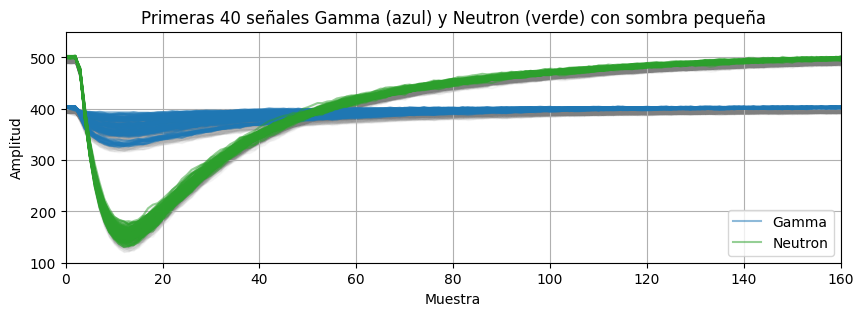

In [20]:
# Explore datasets and plot some signals
print("Gamma dataset shape: ", train_gamma.shape)
print("Neutron dataset shape: ", train_neutron.shape)

plt.figure(figsize=(10, 3))

# Graficar 40 señales gamma en azul con sombra pequeña debajo de la línea
for i in range(100):
    y = train_gamma.iloc[i, :-1]
    x = range(len(y))
    plt.plot(x, y, color='tab:blue', alpha=0.5, label='Gamma' if i == 0 else "")
    plt.fill_between(x, y, y-10, color='tab:gray', alpha=0.05)  # Sombra pequeña

# Graficar 40 señales neutron en verde con sombra pequeña debajo de la línea
for i in range(100):
    y = train_neutron.iloc[i, :-1]
    x = range(len(y))
    plt.plot(x, y, color='tab:green', alpha=0.5, label='Neutron' if i == 0 else "")
    plt.fill_between(x, y, y-10, color='tab:gray', alpha=0.05)  # Sombra pequeña

plt.title("Primeras 40 señales Gamma (azul) y Neutron (verde) con sombra pequeña")
plt.xlabel("Muestra")
plt.ylabel("Amplitud")
plt.xlim(0, 160)
plt.ylim(100, 550)
plt.legend()
plt.grid()
plt.show()

In [ ]:
# cargar csv
df = pd.read_csv("dataset/test_dataset.csv")

# separar clases
class1 = df[df["class"] == 1].iloc[:100, :-1]   # primeras 100 filas clase 1
class0 = df[df["class"] == 0].iloc[:100, :-1]   # primeras 100 filas clase 0

# convertir a listas planas
gamma = class1.to_numpy().flatten()
neutron = class0.to_numpy().flatten()


def write_c_array(file, name, data, width=161):
    file.write(f"int {name}[{len(data)}] = {{\n")

    total_rows = (len(data) + width - 1) // width

    for r, i in enumerate(range(0, len(data), width)):
        row = data[i:i+width]
        # convertir a string
        line = ",".join(str(int(v)) for v in row)
        # quitar coma si es la última fila
        if r == total_rows - 1:
            file.write(f"\t{line}\n")
        else:
            file.write(f"\t{line},\n")
    file.write("};\n\n")


with open("dataset/arrays.txt", "w") as f:
    write_c_array(f, "tracesGamma", gamma)
    write_c_array(f, "tracesNeutron", neutron)

print("Archivo arrays.txt generado")

Archivo arrays.txt generado


---
### Calculo de la Energia y el FCI segun el articulo

In [9]:
def compute_energy_fci(pulses):

    n_events, n_samples = pulses.shape
    energy = np.zeros(n_events)
    fci = np.zeros(n_events)

    for i in range(n_events):
        pulse = pulses[i]
        # ---- ENERGY ----
        baseline = pulse[:20].mean()
        peak = pulse.max()
        energy[i] = peak - baseline
        # ---- FFT ----
        X = np.fft.fft(pulse)
        # city-block magnitude (ASDM)
        mag = np.abs(X.real) + np.abs(X.imag)
        # remove DC component
        mag = mag[1:]
        # PSA windows
        PSA_l = mag[0:25].sum()   # 1–25
        PSA_w = mag[0:90].sum()   # 1–90
        # FCI
        if PSA_w > 0:
            fci[i] = (PSA_w - PSA_l) / PSA_w
        else:
            fci[i] = 0
    return energy, fci

In [10]:
energy_neutron, psd_neutron = compute_energy_fci(newNeutron)
energy_gamma, psd_gamma = compute_energy_fci(newGamma)

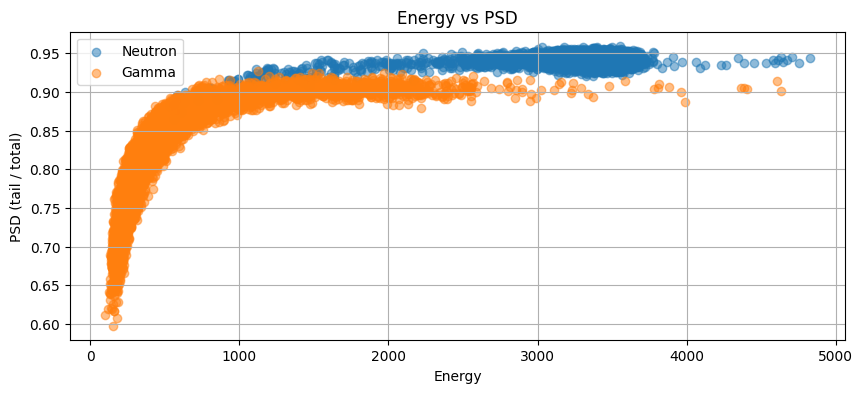

In [11]:
plt.figure(figsize=(10, 4))
plt.scatter(energy_neutron*5000/350, 1-psd_neutron, label='Neutron', alpha=0.5)
plt.scatter(energy_gamma*5000/350, 1-psd_gamma, label='Gamma', alpha=0.5)

plt.xlabel("Energy")
plt.ylabel("PSD (tail / total)")
plt.title("Energy vs PSD")

plt.legend()
plt.grid()
plt.show()